# Online Retail Customer Segmentation
## OASIS INFOBYTE SIP — Data Analytics Level 1, Task 2

This project uses the UCI Online Retail dataset to analyse purchasing behaviour and segment customers using **RFM analysis** and **K-Means clustering**.

The notebook covers data cleaning, exploratory analysis, RFM feature engineering, cluster selection, customer segmentation and business interpretation.

## Objectives
- Clean and validate transaction data.
- Explore sales trends, products and countries.
- Calculate customer-level Recency, Frequency and Monetary (RFM) measures.
- Visualise RFM distributions.
- Select clusters using the Elbow Method and silhouette score.
- Apply K-Means clustering and visualise customer segments.
- Translate findings into business recommendations.

## 1. Dataset source
The dataset is the **Online Retail** dataset from the UCI Machine Learning Repository (Dataset 352), covering transactions from 1 December 2010 to 9 December 2011. UCI reports 541,909 transaction rows and describes the data as a UK-based non-store online retailer.

Citation: Chen, D. (2015). *Online Retail*. UCI Machine Learning Repository. DOI: 10.24432/C5BW33. License: CC BY 4.0.

In [1]:
# Install once if needed:
# %pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', None)

## 2. Load the UCI dataset

In [2]:
online_retail = fetch_ucirepo(id=352)
df = online_retail.data.original.copy()
print('Shape:', df.shape)
display(df.head())

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 3. Data quality checks

In [3]:
print('Duplicate rows:', df.duplicated().sum())
display(df.isna().sum().sort_values(ascending=False).to_frame('missing_values'))
print('Negative quantities:', (df['Quantity'] < 0).sum())
print('Non-positive prices:', (df['UnitPrice'] <= 0).sum())
print('Cancelled invoices:', df['InvoiceNo'].astype(str).str.upper().str.startswith('C').sum())

Duplicate rows: 5268


,missing_values
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


Negative quantities: 10624
Non-positive prices: 2517
Cancelled invoices: 9288


### Cleaning decisions
For customer segmentation, the model should describe completed purchases rather than cancellations or returns. We therefore remove cancelled invoices, negative quantities, non-positive prices, missing customer IDs and duplicate rows.

In [4]:
df = df.drop_duplicates().copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
clean = df[~df['InvoiceNo'].astype(str).str.upper().str.startswith('C') & (df['Quantity'] > 0) & (df['UnitPrice'] > 0) & df['CustomerID'].notna() & df['InvoiceDate'].notna()].copy()
clean['CustomerID'] = clean['CustomerID'].astype(int).astype(str)
clean['Revenue'] = clean['Quantity'] * clean['UnitPrice']
print('Cleaned shape:', clean.shape)
display(clean.head())

Cleaned shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 4. Exploratory analysis

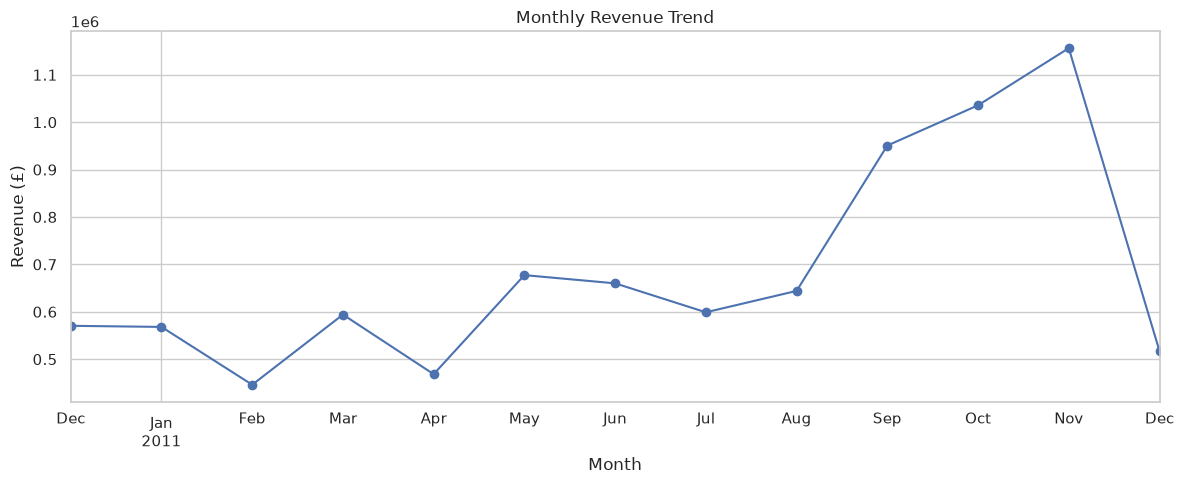

In [5]:
monthly_sales = clean.set_index('InvoiceDate')['Revenue'].resample('MS').sum()
fig, ax = plt.subplots(figsize=(12,5))
monthly_sales.plot(ax=ax, marker='o')
ax.set_title('Monthly Revenue Trend'); ax.set_xlabel('Month'); ax.set_ylabel('Revenue (£)')
plt.tight_layout(); fig.savefig(OUTPUTS/'monthly_revenue_trend.png', dpi=160, bbox_inches='tight'); plt.show()

### 4.1 Monthly Revenue Trend — Analysis
The revenue trend shows how sales performance changes over the observation period and helps identify periods of stronger and weaker commercial activity. Peaks can indicate seasonal demand or successful campaigns, while sustained declines can signal periods that require closer investigation. This establishes the overall sales context before moving into customer-level segmentation.

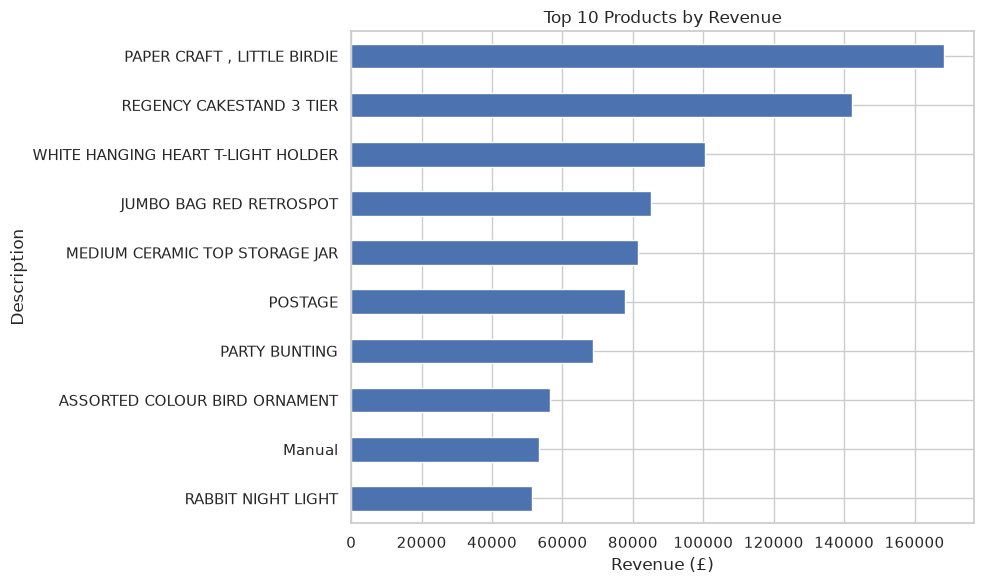

In [6]:
top_products = clean.groupby('Description', dropna=False)['Revenue'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,6))
top_products.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 Products by Revenue'); ax.set_xlabel('Revenue (£)')
plt.tight_layout(); fig.savefig(OUTPUTS/'top_10_products_by_revenue.png', dpi=160, bbox_inches='tight'); plt.show()

### 4.2 Top 10 Products by Revenue — Analysis
This visual identifies the products contributing most strongly to revenue. A concentration of revenue among a small number of products would suggest that these items deserve particular attention in inventory planning, promotions and cross-selling strategies. Lower-ranked products can also reveal opportunities to improve product visibility or bundle complementary items.

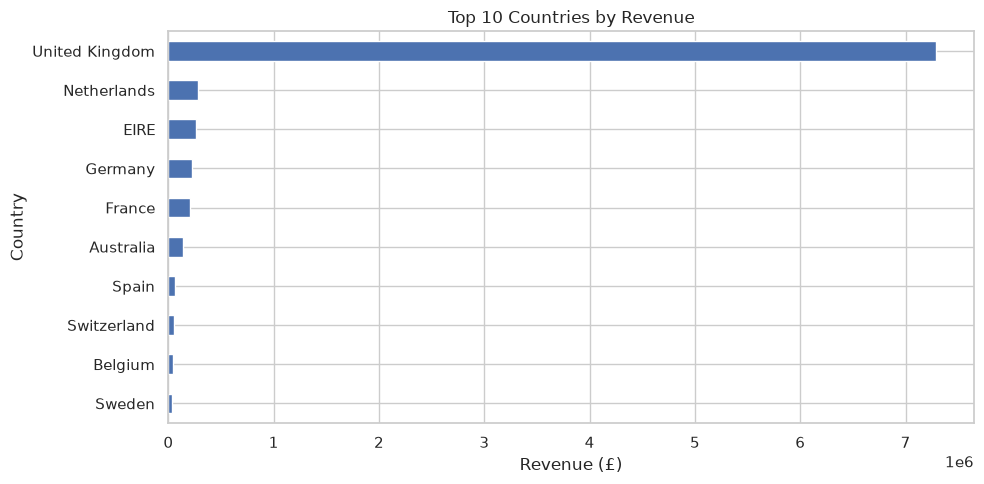

In [7]:
country_sales = clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,5))
country_sales.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 Countries by Revenue'); ax.set_xlabel('Revenue (£)')
plt.tight_layout(); fig.savefig(OUTPUTS/'top_10_countries_by_revenue.png', dpi=160, bbox_inches='tight'); plt.show()

### 4.3 Top 10 Countries by Revenue — Analysis
The country-level view shows where the retailer's revenue is geographically concentrated. The ranking can support decisions about market prioritisation, localisation, shipping strategy and international customer acquisition. It also provides useful context for interpreting customer behaviour beyond the home market.

## 5. Build the RFM table

In [8]:
snapshot_date = clean['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = clean.groupby('CustomerID').agg(Recency=('InvoiceDate', lambda x: (snapshot_date-x.max()).days), Frequency=('InvoiceNo','nunique'), Monetary=('Revenue','sum')).reset_index()
display(rfm.describe().round(2)); display(rfm.head())

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


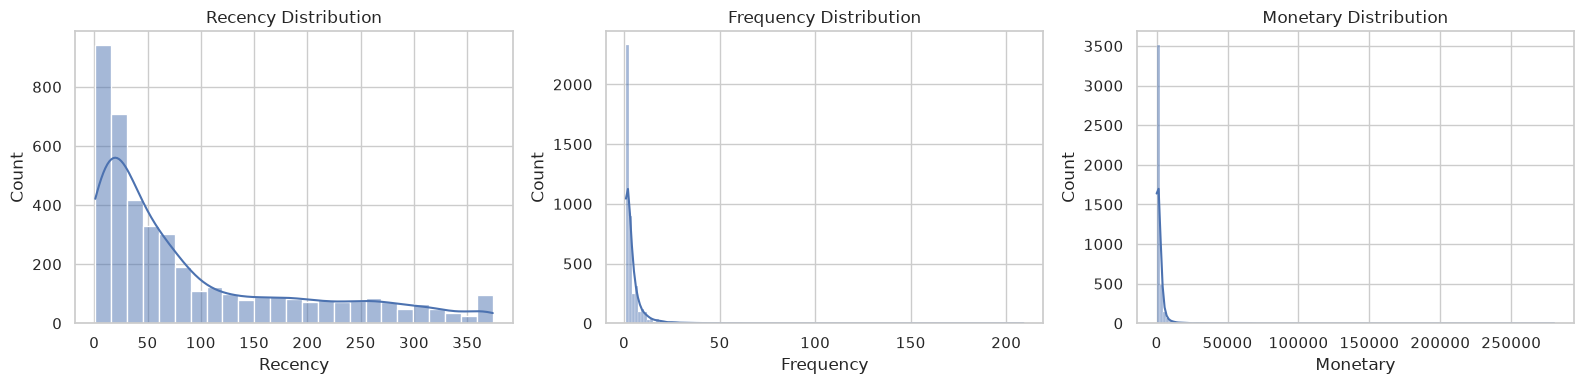

In [9]:
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax, column in zip(axes,['Recency','Frequency','Monetary']):
    sns.histplot(rfm[column], kde=True, ax=ax)
    ax.set_title(f'{column} Distribution')
plt.tight_layout(); fig.savefig(OUTPUTS/'rfm_distributions.png', dpi=160, bbox_inches='tight'); plt.show()

### 5.1 RFM Distributions — Analysis
The RFM distributions show that customer behaviour is not uniform. Recency measures how recently customers purchased, Frequency measures repeat purchasing, and Monetary value measures customer revenue contribution. These distributions justify transforming and standardising the RFM variables before clustering so that highly skewed values do not dominate the model.

## 6. Prepare RFM features for K-Means
RFM variables are typically right-skewed, so a log transformation helps reduce the influence of very large customers. The features are then standardised so Recency, Frequency and Monetary value contribute on comparable scales.

In [10]:
rfm_features = rfm[['Recency','Frequency','Monetary']].copy()
rfm_log = np.log1p(rfm_features)
scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)
print('Customers available for segmentation:', len(rfm))

Customers available for segmentation: 4338


## 7. Select the number of clusters

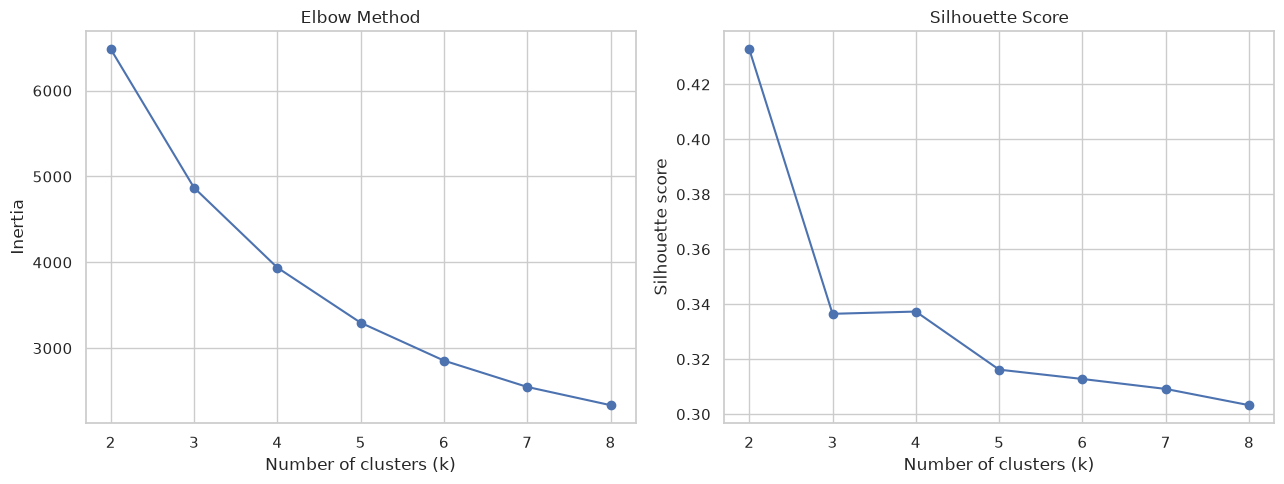

,k,inertia,silhouette
0,2,6483.5894,0.4328
1,3,4869.4886,0.3365
2,4,3938.6032,0.3373
3,5,3296.7087,0.3162
4,6,2855.5256,0.3128
5,7,2548.8202,0.3092
6,8,2336.3411,0.3033


Highest silhouette score occurs at k = 2


In [11]:
inertias=[]; silhouette_scores=[]; k_values=range(2,9)
for k in k_values:
    model=KMeans(n_clusters=k, random_state=42, n_init=20)
    labels=model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
fig, axes=plt.subplots(1,2,figsize=(13,5))
axes[0].plot(list(k_values),inertias,marker='o'); axes[0].set_title('Elbow Method'); axes[0].set_xlabel('Number of clusters (k)'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(k_values),silhouette_scores,marker='o'); axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('Number of clusters (k)'); axes[1].set_ylabel('Silhouette score')
plt.tight_layout(); fig.savefig(OUTPUTS/'cluster_selection.png',dpi=160,bbox_inches='tight'); plt.show()
scores=pd.DataFrame({'k':list(k_values),'inertia':inertias,'silhouette':silhouette_scores}); display(scores.round(4))
best_k=int(scores.loc[scores['silhouette'].idxmax(),'k']); print('Highest silhouette score occurs at k =',best_k)

### 7.1 Cluster Selection — Analysis
The Elbow Method provides a view of diminishing returns as more clusters are added, while the silhouette score evaluates how clearly separated the resulting groups are. The notebook selects the value of **k** with the highest silhouette score, providing an objective basis for the final K-Means configuration rather than choosing the number of segments arbitrarily.

## 8. Fit K-Means and profile the segments

In [12]:
kmeans=KMeans(n_clusters=best_k,random_state=42,n_init=20)
rfm['Cluster']=kmeans.fit_predict(X)
cluster_profile=rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].agg(['mean','median','count']).round(2)
display(cluster_profile)

Recency              Frequency              Monetary               
           mean median count      mean median count     mean   median count
Cluster                                                                    
0        134.09   96.0  2672      1.67    1.0  2672   495.59   363.08  2672
1         25.89   16.0  1666      8.44    6.0  1666  4539.60  2061.08  1666

<function matplotlib.pyplot.show(close=None, block=None)>

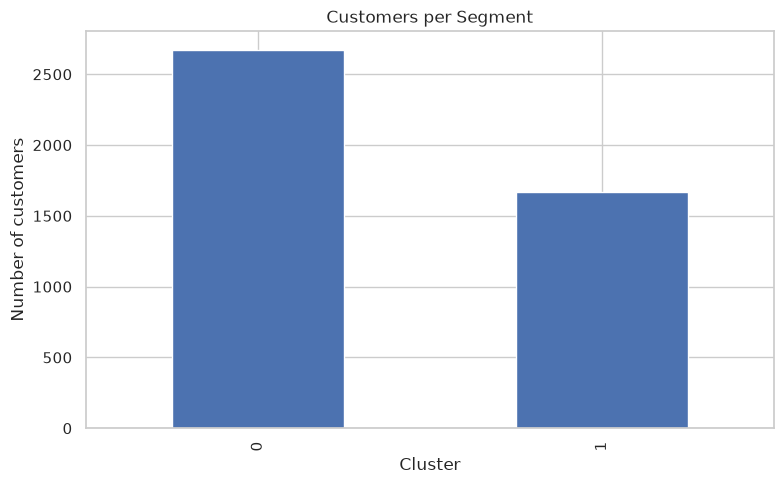

In [13]:
cluster_counts=rfm['Cluster'].value_counts().sort_index()
fig,ax=plt.subplots(figsize=(8,5)); cluster_counts.plot(kind='bar',ax=ax)
ax.set_title('Customers per Segment'); ax.set_xlabel('Cluster'); ax.set_ylabel('Number of customers')
plt.tight_layout(); fig.savefig(OUTPUTS/'customers_per_segment.png',dpi=160,bbox_inches='tight'); plt.show

### 8.1 Customers per Segment — Analysis
The final clustering produces two customer groups. **Cluster 0 contains 2,672 customers**, while **Cluster 1 contains 1,666 customers**. Cluster 0 is therefore the larger segment, representing the majority of customers in the final segmentation. This difference in segment size is important when prioritising campaigns because strategies aimed at the larger group have greater potential reach.

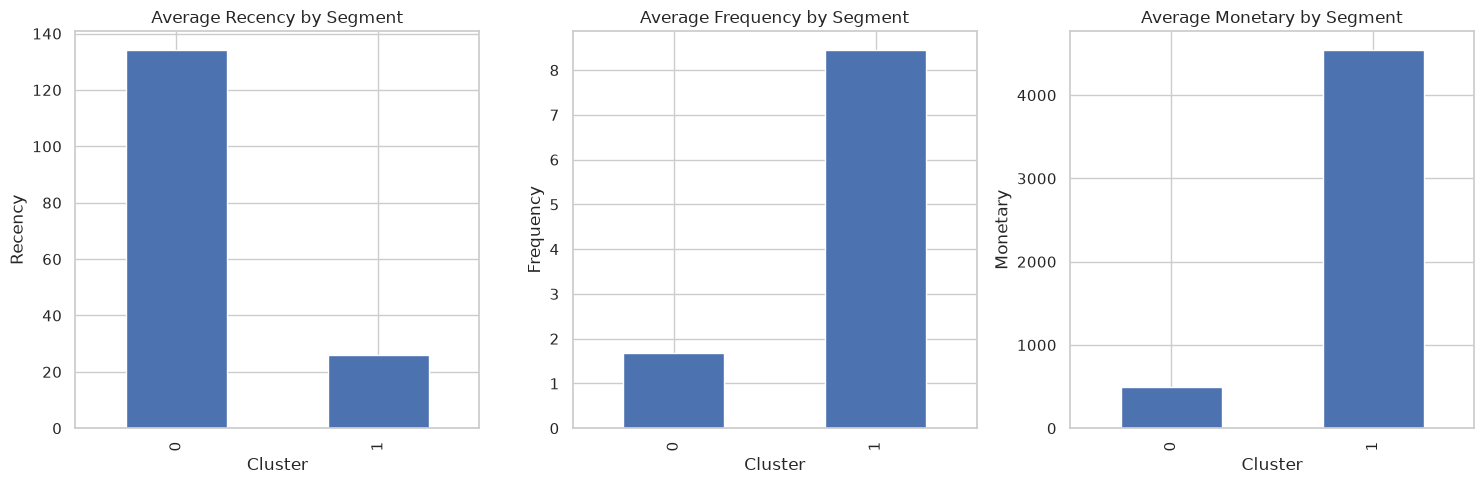

In [14]:
cluster_means=rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,column in zip(axes,['Recency','Frequency','Monetary']):
    cluster_means[column].plot(kind='bar',ax=ax)
    ax.set_title(f'Average {column} by Segment'); ax.set_xlabel('Cluster'); ax.set_ylabel(column)
plt.tight_layout(); fig.savefig(OUTPUTS/'rfm_by_segment.png',dpi=160,bbox_inches='tight'); plt.show()

### 8.2 Average RFM by Segment — Analysis
The segment profiles reveal a strong behavioural contrast. **Cluster 1 averages 25.89 days of recency, 8.44 purchases and £4,539.60 in monetary value**, compared with **Cluster 0 at 134.09 days, 1.67 purchases and £495.59**. Cluster 1 is therefore the clearly more recent, frequent and valuable customer group, while Cluster 0 represents customers who purchase less frequently, spend considerably less and have been inactive for longer.

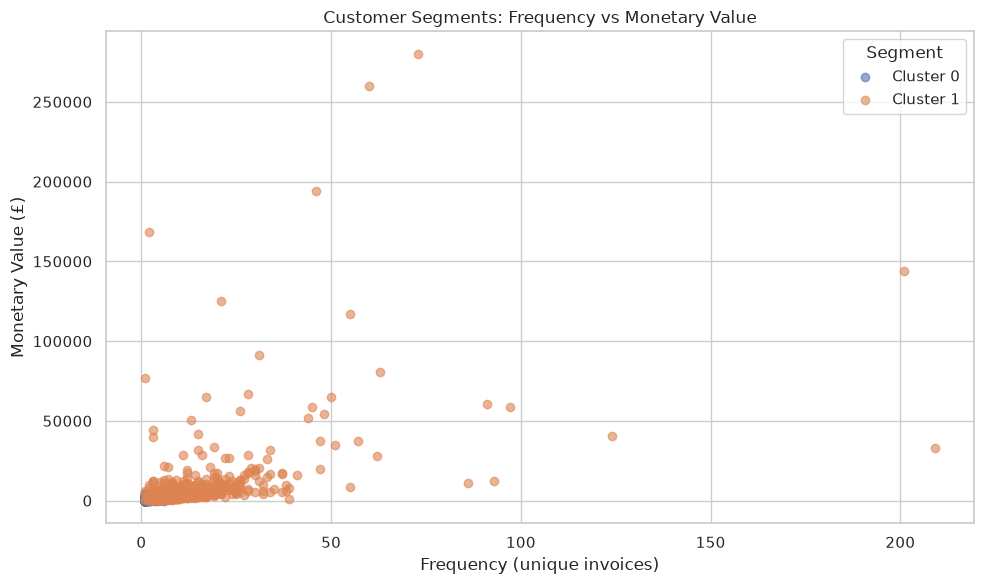

In [15]:
fig,ax=plt.subplots(figsize=(10,6))
for cluster in sorted(rfm['Cluster'].unique()):
    subset=rfm[rfm['Cluster']==cluster]
    ax.scatter(subset['Frequency'],subset['Monetary'],label=f'Cluster {cluster}',alpha=0.6)
ax.set_title('Customer Segments: Frequency vs Monetary Value'); ax.set_xlabel('Frequency (unique invoices)'); ax.set_ylabel('Monetary Value (£)'); ax.legend(title='Segment')
plt.tight_layout(); fig.savefig(OUTPUTS/'customer_segments_scatter.png',dpi=160,bbox_inches='tight'); plt.show()

### 8.3 Frequency vs Monetary Value — Analysis
The scatter plot reinforces the difference between the two segments: customers who purchase more frequently tend to appear alongside higher monetary values in the stronger-value group. The visual helps demonstrate that the segmentation is not based on a single measure; it captures broader purchasing behaviour across repeat activity and customer value.

## 9. Customer segment interpretation

In [16]:
profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
profile['Recency_rank'] = profile['Recency'].rank(ascending=True)
profile['Frequency_rank'] = profile['Frequency'].rank(ascending=False)
profile['Monetary_rank'] = profile['Monetary'].rank(ascending=False)
display(profile.sort_values('Monetary', ascending=False).round(2))

,Recency,Frequency,Monetary,Recency_rank,Frequency_rank,Monetary_rank
Cluster,,,,,,
1,25.89,8.44,4539.60,1.0,1.0,1.0
0,134.09,1.67,495.59,2.0,2.0,2.0


## 10. Visual Analysis & Key Findings
The repository contains the final polished visual outputs used to communicate the analysis. Each visual is presented with an interpretation so that the charts function as evidence for the conclusions rather than appearing as standalone images.

### 10.1 Monthly Revenue Trend
![Monthly Revenue Trend](../outputs/01_monthly_revenue_trend.png)

**Analysis:** The monthly trend provides the commercial context for the project by showing changes in revenue over time. Periods of stronger revenue indicate higher-demand trading periods, while weaker periods can be investigated for seasonality, customer engagement or product availability.

### 10.2 Top 10 Countries by Revenue
![Top 10 Countries by Revenue](../outputs/02_top_10_countries_revenue.png)

**Analysis:** The country ranking shows where revenue is concentrated geographically. This can inform market prioritisation, international marketing and fulfilment decisions, while also highlighting the importance of understanding customers outside the retailer's primary market.

### 10.3 Top 10 Products by Revenue
![Top 10 Products by Revenue](../outputs/03_top_10_products_revenue.png)

**Analysis:** The product ranking identifies the items generating the strongest revenue contribution. These products can be prioritised for inventory availability, promotion and cross-selling, while lower-performing products may require further investigation.

### 10.4 Recency Distribution
![Recency Distribution](../outputs/04_recency_distribution.png)

**Analysis:** Recency indicates how recently customers interacted with the retailer. A wide distribution shows that the customer base contains both recently active customers and customers who have been inactive for longer periods, supporting the need for differentiated retention and reactivation strategies.

### 10.5 Frequency Distribution
![Frequency Distribution](../outputs/05_frequency_distribution.png)

**Analysis:** Frequency captures repeat purchasing behaviour. Customers with higher purchase counts represent stronger engagement and are particularly useful for identifying loyal or high-potential customers.

### 10.6 Monetary Distribution
![Monetary Distribution](../outputs/06_monetary_distribution.png)

**Analysis:** Monetary value highlights differences in customer revenue contribution. The distribution supports the use of segmentation because a relatively small group of customers can have substantially different commercial value from the broader customer base.

### 10.7 Silhouette Scores & Cluster Selection
![Silhouette Scores](../outputs/07_silhouette_scores.png)

**Analysis:** The clustering evaluation compares candidate values of k and supports the selected segmentation size. The final model uses the k with the strongest silhouette score, making the number of segments evidence-based rather than subjective.

### 10.8 Customers per Segment
![Customers per Segment](../outputs/08_customers_per_segment.png)

**Analysis:** The final model contains **2,672 customers in Cluster 0 and 1,666 customers in Cluster 1**. Cluster 0 is the larger group, while Cluster 1 is smaller but substantially stronger on RFM value.

### 10.9 Average RFM by Segment
![Average RFM by Segment](../outputs/09_average_rfm_by_segment.png)

**Analysis:** Cluster 1 has a much lower average recency (**25.89 days**), higher frequency (**8.44 purchases**) and much higher monetary value (**£4,539.60**) than Cluster 0 (**134.09 days, 1.67 purchases and £495.59**). This makes Cluster 1 the clear high-value and highly engaged segment, while Cluster 0 is the lower-engagement group requiring reactivation or nurturing.

### 10.10 Frequency vs Monetary Value
![Frequency vs Monetary Segments](../outputs/10_frequency_vs_monetary_segments.png)

**Analysis:** This view demonstrates the relationship between repeat purchasing and customer value. The stronger segment is characterised by higher purchasing activity and substantially greater monetary contribution, confirming that the RFM variables separate customers by meaningful commercial behaviour.

### 10.11 Recency vs Monetary Value
![Recency vs Monetary Segments](../outputs/11_recency_vs_monetary_segments.png)

**Analysis:** Combining recency with monetary value helps distinguish recently active, high-value customers from customers whose spending is accompanied by longer periods of inactivity. This is particularly useful for deciding between retention and reactivation campaigns.

### 10.12 3D RFM Customer Segments
![3D RFM Customer Segments](../outputs/12_3d_rfm_customer_segments.png)

**Analysis:** The 3D view brings Recency, Frequency and Monetary value together, providing an overall picture of how the two customer groups differ across all three dimensions. The separation supports the conclusion that the clustering captures distinct purchasing profiles rather than differences in only one metric.

## 11. Customer Segment Profiles & Business Recommendations

### Segment 1 — High-Value & Highly Engaged Customers
**Cluster 1:** 1,666 customers | Avg. recency: 25.89 days | Avg. frequency: 8.44 purchases | Avg. monetary value: £4,539.60

These customers are recently active, purchase repeatedly and contribute substantially more revenue. They should be treated as a priority retention segment through personalised recommendations, loyalty incentives, early access and cross-selling.

### Segment 2 — Lower-Engagement / Reactivation Customers
**Cluster 0:** 2,672 customers | Avg. recency: 134.09 days | Avg. frequency: 1.67 purchases | Avg. monetary value: £495.59

This larger segment has lower purchase frequency, lower monetary contribution and substantially higher recency. It is a strong candidate for targeted reactivation campaigns, personalised promotions, product recommendations and incentives designed to encourage a repeat purchase.

### Business takeaway
The most important finding is that customer value is highly uneven. The smaller Cluster 1 group has far stronger engagement and monetary contribution, while the larger Cluster 0 group represents a sizeable opportunity for reactivation and customer development. The business should therefore avoid treating all customers identically and instead allocate retention resources according to measurable customer behaviour.

## 12. Conclusion
The analysis combines exploratory data analysis, RFM feature engineering and unsupervised learning to identify meaningful groups of online retail customers. The final two-segment solution reveals a clear distinction between a smaller, recently active and high-value customer group and a larger, lower-engagement group. These findings provide a practical foundation for targeted retention, reactivation and customer-value strategies.

### Additional cluster visualisation — Recency vs Frequency
This second feature combination complements Frequency vs Monetary Value and shows how recent activity differs across the customer segments.


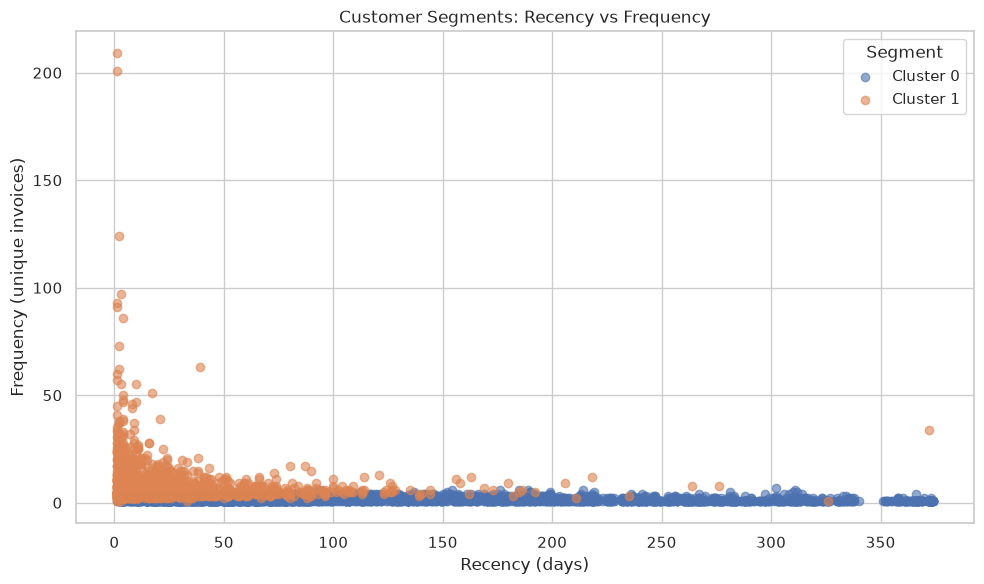

In [17]:
fig, ax = plt.subplots(figsize=(10,6))
for cluster in sorted(rfm['Cluster'].unique()):
    subset = rfm[rfm['Cluster'] == cluster]
    ax.scatter(subset['Recency'], subset['Frequency'], label=f'Cluster {cluster}', alpha=0.6)
ax.set_title('Customer Segments: Recency vs Frequency')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (unique invoices)')
ax.legend(title='Segment')
plt.tight_layout()
fig.savefig(OUTPUTS/'customer_segments_scatter_recency_frequency.png', dpi=160, bbox_inches='tight')
plt.show()


## Customer segment types and recommended marketing actions


In [18]:
segment_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
rows = []
for cluster, row in segment_profile.iterrows():
    if row['Recency'] <= rfm['Recency'].median() and row['Frequency'] >= rfm['Frequency'].median() and row['Monetary'] >= rfm['Monetary'].median():
        customer_type = 'High-value / loyal'
        action = 'Protect with loyalty rewards, early access and personalised cross-sell offers.'
    elif row['Recency'] > rfm['Recency'].median() and row['Frequency'] < rfm['Frequency'].median():
        customer_type = 'At-risk / inactive'
        action = 'Run win-back campaigns, reminders and targeted incentives to reactivate.'
    else:
        customer_type = 'Developing / opportunity'
        action = 'Use personalised recommendations, bundles and promotions to increase frequency and value.'
    rows.append([cluster, row['Recency'], row['Frequency'], row['Monetary'], customer_type, action])
segment_summary = pd.DataFrame(rows, columns=['Cluster','Recency','Frequency','Monetary','CustomerType','RecommendedMarketingAction'])
display(segment_summary)
segment_summary.to_csv(OUTPUTS/'segment_profile_and_actions.csv', index=False)


,Cluster,Recency,Frequency,Monetary,CustomerType,RecommendedMarketingAction
0,0,134.09,1.67,495.59,At-risk / inactive,"Run win-back campaigns, reminders and targeted..."
1,1,25.89,8.44,4539.60,High-value / loyal,"Protect with loyalty rewards, early access and..."
